# U-net as Image Denoiser for ZTF stamps (I)
```Authors: Paul Alvarez updated: 20260804```

This study implements the U-net architecture (defined in utils) on u_net_model.py and evaluates the performance of it as a image denoiser on ZTF stamps obtained via Alerce API. ZTF stamps are real images obtained from the Palomar Observatory (San Diego, USA) meaning they can inherently contain noise. For the purposes of this study, artificial noise will be added to analyze the differences with the raw image. The main objective is train a U-Net neural network to reconstruct synthetically degraded astronomical images and study which types of noise it can learn to remove.

## Required libraries

In [24]:
from alerce.core import Alerce
from astropy.io import fits
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from astropy.io.fits.verify import VerifyWarning
from pathlib import Path

import warnings
import json
import os
import time
import sqlalchemy as sa
import requests
import pandas as pd
import numpy as np
import sys
import cv2
import matplotlib.pyplot as plt

warnings.simplefilter('ignore', category=VerifyWarning)

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from utils.functions import *

## Introduction

U-Net is a convolutional neural network that was developed for image segmentation. This architecture consist of a contracting path (adding continuos convolutional layers and pooling in each step) to capture context and a symmetric expanding path (retrieving the original shape from the convolutional layers by upsampling operators and combining with features obtained in the contracting path) that enables precise localization.


In this notebook, we cover the implementation of U-Net, testing it as an image denoiser. The architecture reamins the same; however, modifications were introduced to the data loading (for handling the .fits dataset), loss function (used MCE loss for comparing each pixel between noisy and clean image) and optimizer in order to solve this type of  reconstruction problem.





## Dataset

### Query API

In [2]:
# Connect to the ALeRCE API according to their instructions
client = Alerce()

url = "https://raw.githubusercontent.com/alercebroker/usecases/master/alercereaduser_v4.json"
params = requests.get(url).json()['params']

engine = sa.create_engine(f"postgresql+psycopg2://{params['user']}:{params['password']}@{params['host']}/{params['dbname']}")
engine.begin()

In [7]:
# API queries to obtain data
query = """
(
    SELECT DISTINCT ON (oid) oid, class_name
    FROM probability
    WHERE classifier_name = 'stamp_classifier'
      AND probability >= 0.76
      AND class_name = 'SN'
    LIMIT 1250
)
UNION ALL
(
    SELECT DISTINCT ON (oid) oid, class_name
    FROM probability
    WHERE classifier_name = 'stamp_classifier'
      AND probability >= 0.90
      AND class_name = 'VS'
    LIMIT 1250
);
"""

df_real = pd.read_sql_query(query, engine)

In [8]:
# API queries to obtain data
query = """
SELECT DISTINCT ON (o.oid)
       o.oid,
       p.class_name
FROM object o
JOIN probability p
ON o.oid = p.oid
WHERE p.classifier_name = 'stamp_classifier'
  AND p.class_name = 'bogus'
ORDER BY o.oid, p.probability DESC
LIMIT 2500;  
"""

df_bogus = pd.read_sql_query(query, engine)

In [9]:
# df_real and df_bogus are the results of each query; we combine them to form our dataset
df_ztf = pd.concat([df_real, df_bogus], ignore_index=True)
df_ztf['label'] = df_ztf['class_name'].apply(lambda x: 0 if x=='bogus' else 1)
df_ztf = df_ztf.sample(frac=1, random_state=42).reset_index(drop=True) # no data leakage due to label position

df_ztf["class_name"].value_counts(normalize=True) * 100

class_name
bogus    50.0
VS       25.0
SN       25.0
Name: proportion, dtype: float64

In [10]:
# Save CSV of labels with only the oid and its label to apply CNN's
DATA_DIR_LABEL = "../data/labels"
os.makedirs(DATA_DIR_LABEL, exist_ok=True)
labels_save_path = os.path.join(DATA_DIR_LABEL, "labels_real_vs_bogus.csv")

df_ztf[['oid','label']].to_csv(labels_save_path, index=False)
df_ztf.head()

,oid,class_name,label
0,ZTF17aabcraf,VS,1
1,ZTF17aaaaaiu,bogus,0
2,ZTF17aaaaanw,bogus,0
3,ZTF18aazdgfr,SN,1
4,ZTF18aaxjvmh,SN,1


### Download stamps

In [11]:
# Download the images associated with each observation (oid is the key for each one)
DATA_DIR_STAMPS = "../data/stamps"
labels = pd.read_csv(labels_save_path)
to_delete=  [] # Store the corrupt (trigger exception) oid to delete them
oids_to_download = labels['oid'].tolist()

if not os.path.exists(DATA_DIR_STAMPS):
    os.makedirs(DATA_DIR_STAMPS)

In [12]:
# Parallel API requests to improve performance
with ThreadPoolExecutor(max_workers=7) as executor:
    futures = {
        executor.submit(download_stamp, oid, client, DATA_DIR_STAMPS, to_delete): oid 
        for oid in oids_to_download
    }

    for future in tqdm(as_completed(futures), total=len(oids_to_download), desc="Download Stamps"):
        oid = futures[future]

        try:
            ok = future.result()
            
        except Exception as e:
            # tqdm.write(f"ERROR {oid}: {e}")
            pass

Download Stamps:   0%|          | 0/5000 [00:00<?, ?it/s]

## Gaussian Noise

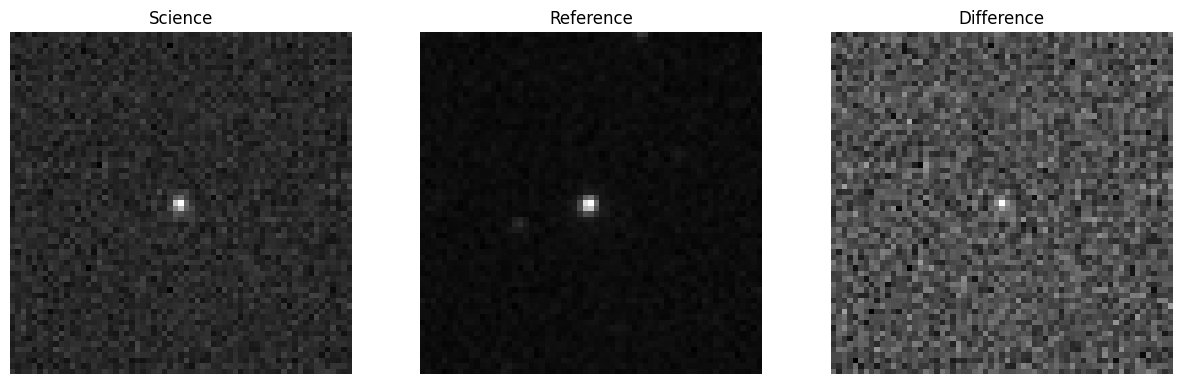

In [ ]:
# Display a sample .fits file to verify it was loaded correctly
path = f"{DATA_DIR_STAMPS}/ZTF17aabqcyh_stamps.fits"
visual_fits(path)

In [44]:
def add_gaussian_noise(img_path, OUTPUT_DIR= None, mean= 0, std= 25):
    # Open a .fits file and add gaussian noise to it
    oid = Path(img_path).stem
    save_path = f"{OUTPUT_DIR}/{oid}_noisy.fits"
    if Path(save_path).exists(): return save_path
    
    hdu = fits.open(img_path)
    img = hdu[0].data
    header = hdu[0].header

    noise = np.random.normal(mean, std, img.shape)
    noisy_image = img + noise
    
    if OUTPUT_DIR != None: fits.writeto(save_path, noisy_image, header, overwrite=True)
    hdu.close()

    return noisy_image

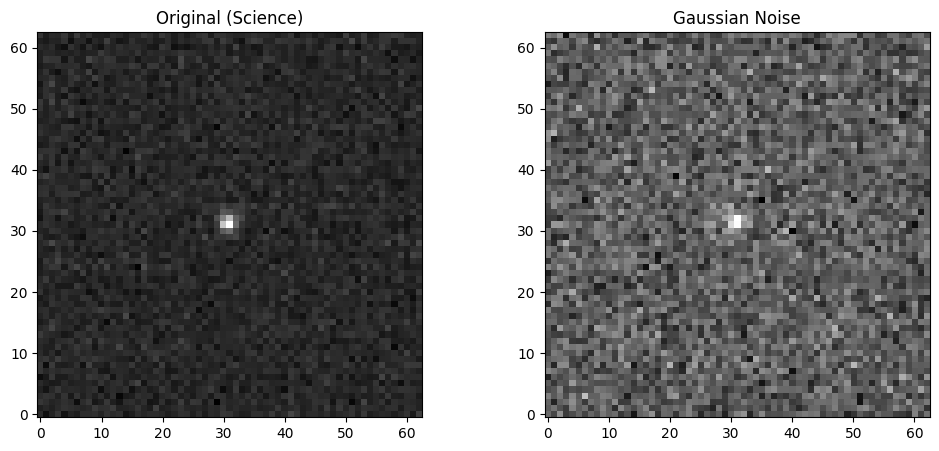

In [46]:
# Using only science image to testing some noise
hdu = fits.open(path)
science_img = hdu[0].data
noisy_image = add_gaussian_noise(path, OUTPUT_DIR= None, mean= 1, std= 30)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(science_img, cmap="gray", origin="lower")
ax[0].set_title("Original (Science)")
ax[1].imshow(noisy_image, cmap="gray", origin="lower")
ax[1].set_title("Gaussian Noise")

plt.show()

In [45]:
# Add gaussian noise to our dataset
DATA_DIR_NOISY = "../data/gaussian_noise"
os.makedirs(DATA_DIR_NOISY, exist_ok=True)

stamps_fits = Path(DATA_DIR_STAMPS)
for archivo in stamps_fits.iterdir():
    add_gaussian_noise(archivo, DATA_DIR_NOISY)